# Transmilenio Router — Exploratory Data Analysis
Setup and data loading for the routing engine.

In [7]:
import sys

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

sys.path.append("..")

from src.graph import build_graph, graph_summary

routes = pd.read_csv("../data/processed/routes.csv")
stations = pd.read_csv("../data/processed/stations.csv")
trunk_lines = pd.read_csv("../data/processed/trunk_lines.csv")

## 1. Raw Data Overview

In [3]:
print("=== TRUNK LINES ===")
display(trunk_lines)

print("=== STATIONS ===")
print(stations.shape)
display(stations.head())
display(stations.info())

print("=== ROUTES ===")
print(routes.shape)
display(routes.head())
display(routes.info())

=== TRUNK LINES ===


,ID,Name
0,A,Caracas
1,B,Autopista Norte
2,C,Suba
3,D,Calle 80
4,E,NQS Central
5,F,Americas
6,G,NQS Sur
7,H,Caracas Sur
8,J,Eje Ambiental
9,K,Calle 26


=== STATIONS ===
(141, 3)


,Zone_ID,Zone_Name,Station_Name
0,A,Caracas,AV. Jiménez - Caracas
1,A,Caracas,Calle 22
2,A,Caracas,Calle 34
3,A,Caracas,Calle 45 - American School Way
4,A,Caracas,Marly


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Zone_ID       141 non-null    object
 1   Zone_Name     141 non-null    object
 2   Station_Name  141 non-null    object
dtypes: object(3)
memory usage: 3.4+ KB


None

=== ROUTES ===
(1386, 4)


,Route_ID,Final_Destination,Stop_Order,Station_Name
0,1,Universidades – CityU,1,Portal El Dorado – C.C. Nuestro Bogotá
1,1,Universidades – CityU,2,Modelia
2,1,Universidades – CityU,3,Normandía
3,1,Universidades – CityU,4,Avenida Rojas - UNISALESIANA
4,1,Universidades – CityU,5,El Tiempo – Cámara de Comercio de Bogotá


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Route_ID           1386 non-null   object
 1   Final_Destination  1386 non-null   object
 2   Stop_Order         1386 non-null   int64 
 3   Station_Name       1386 non-null   object
dtypes: int64(1), object(3)
memory usage: 43.4+ KB


None

## 2. Station Coverage by Zone

Zone_Name
Autopista Norte    17
Americas           16
Caracas Sur        16
NQS Sur            16
Calle 26           14
Suba               14
Calle 80           13
NQS Central        13
Carrera 10         10
Caracas             8
Eje Ambiental       3
Carrera 7           1
Name: Station_Name, dtype: int64


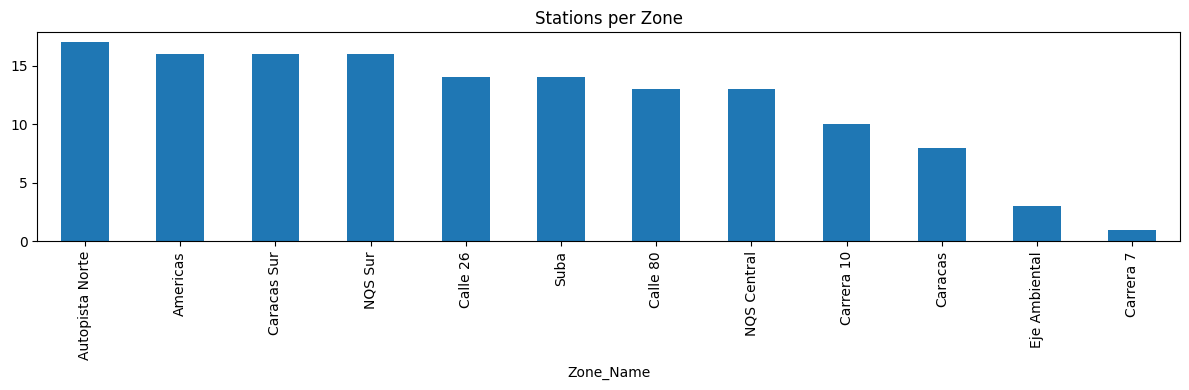

In [4]:
stations_per_zone = (
    stations.groupby("Zone_Name")["Station_Name"].count().sort_values(ascending=False)
)
print(stations_per_zone)

stations_per_zone.plot(kind="bar", figsize=(12, 4), title="Stations per Zone")
plt.tight_layout()
plt.show()

## 3. Route Analysis

Stops per route (min/max/mean):
count    97.000000
mean     14.288660
std       4.043922
min       6.000000
25%      11.000000
50%      14.000000
75%      16.000000
max      25.000000
Name: Station_Name, dtype: float64


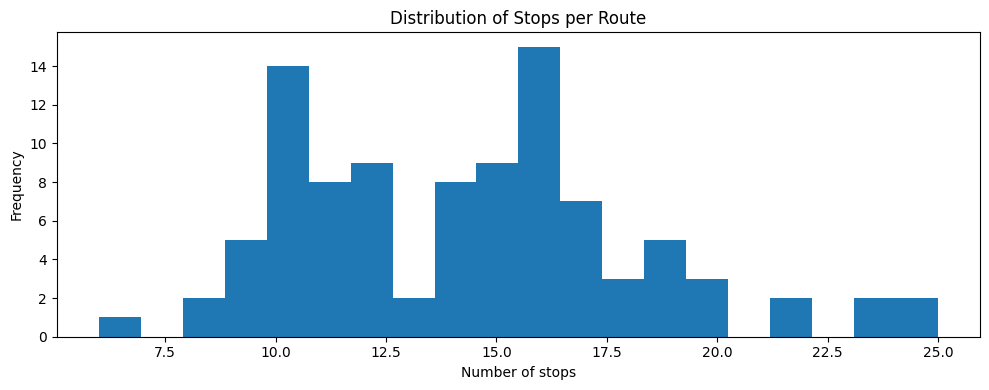


Longest routes:


Route_ID  Final_Destination                
8         Guatoque - Veraguas                  25
          Terminal                             25
4         Héroes                               24
          Portal Sur - JFK Coop. Financiera    24
C17       Portal Suba                          22
Name: Station_Name, dtype: int64


Shortest routes:


Route_ID  Final_Destination    
G45       San Mateo - CC Unisur    6
L41       Bicentenario             8
G41       San Mateo - CC Unisur    8
G46       San Mateo - CC Unisur    9
C73       Portal Suba              9
Name: Station_Name, dtype: int64

In [5]:
stops_per_route = routes.groupby(["Route_ID", "Final_Destination"])[
    "Station_Name"
].count()
print("Stops per route (min/max/mean):")
print(stops_per_route.describe())

stops_per_route.plot(
    kind="hist", bins=20, figsize=(10, 4), title="Distribution of Stops per Route"
)
plt.xlabel("Number of stops")
plt.tight_layout()
plt.show()

print("\nLongest routes:")
display(stops_per_route.sort_values(ascending=False).head(5))

print("\nShortest routes:")
display(stops_per_route.sort_values().head(5))

## 4. Graph Statistics

{'nodes': 141, 'edges': 1289, 'is_connected': True, 'components': 1}


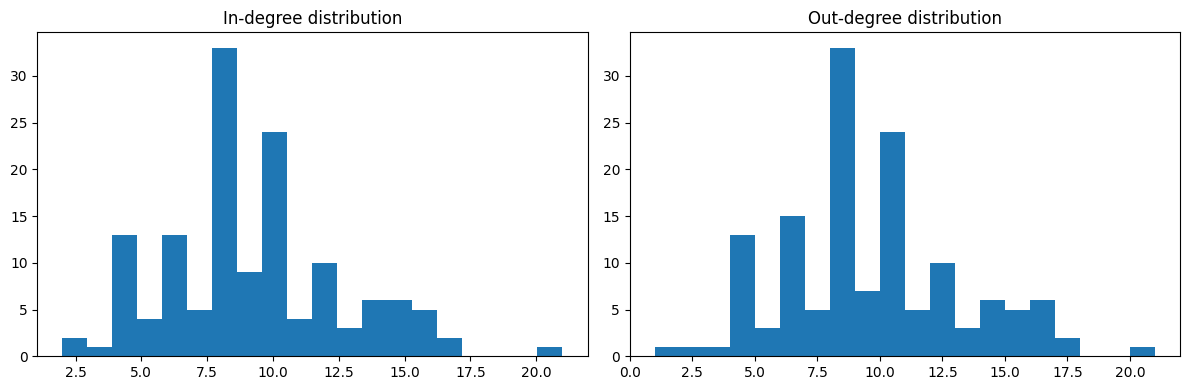


Terminal stations (degree 0 in one direction): 0
[]


In [6]:
G = build_graph()
print(graph_summary(G))

in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(in_degrees.values(), bins=20)
axes[0].set_title("In-degree distribution")
axes[1].hist(out_degrees.values(), bins=20)
axes[1].set_title("Out-degree distribution")
plt.tight_layout()
plt.show()

# Dead-end stations (in or out degree = 0)
dead_ends = [n for n in G.nodes if G.in_degree(n) == 0 or G.out_degree(n) == 0]
print(f"\nTerminal stations (degree 0 in one direction): {len(dead_ends)}")
print(dead_ends)

## 5. Excluded Data Documentation

The following routes were excluded as they are street-stop or feeder routes outside the trunk system:
`D81, K86, L81, L82, M82, M84, M85, M86, C84, P85, A61`

The following stations were excluded as they don't appear in any active route:
`Tercer Milenio, Calle 19, Calle 26, AV. 39, Calle 63, Calle 72, Patio Bonito, SENA, Hospital`

## 6. Hub Stations — Who are the backbone nodes?
Which stations have the most routes passing through them?

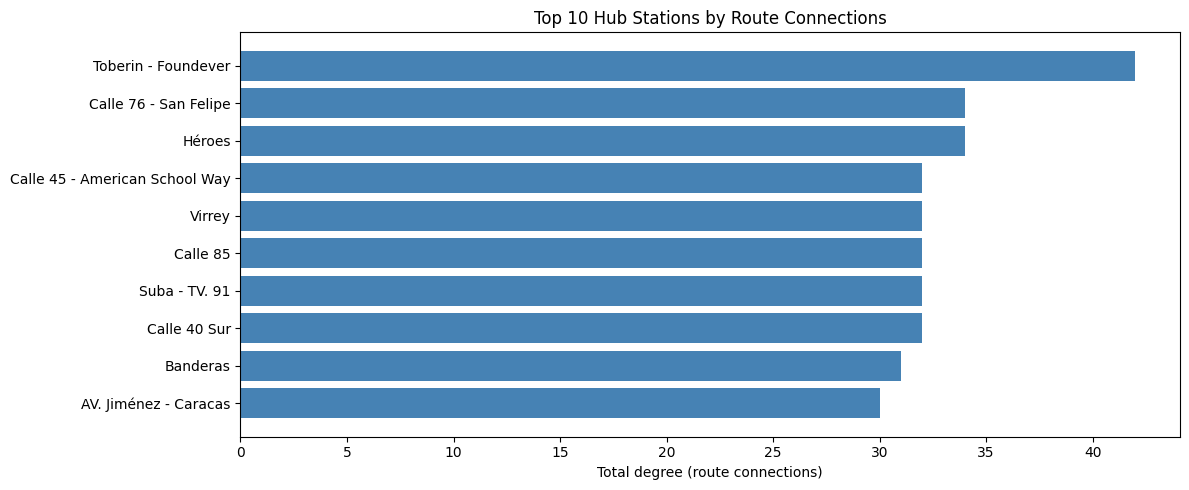

In [8]:
# Total degree = in + out (total route connections)
total_degree = dict(G.degree())
top_hubs = sorted(total_degree.items(), key=lambda x: x[1], reverse=True)[:10]

hub_names = [h[0] for h in top_hubs]
hub_degrees = [h[1] for h in top_hubs]

plt.figure(figsize=(12, 5))
plt.barh(hub_names[::-1], hub_degrees[::-1], color="steelblue")
plt.xlabel("Total degree (route connections)")
plt.title("Top 10 Hub Stations by Route Connections")
plt.tight_layout()
plt.show()

## 7. Route Length Profile — Express vs Local
Are most routes short local services or long cross-city lines?

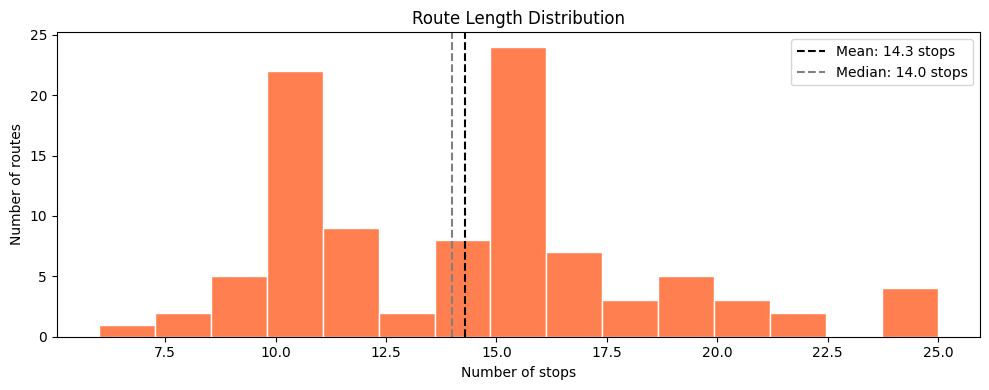

count    97.000000
mean     14.288660
std       4.043922
min       6.000000
25%      11.000000
50%      14.000000
75%      16.000000
max      25.000000
Name: Station_Name, dtype: float64


In [9]:
stops_per_route = routes.groupby(["Route_ID", "Final_Destination"])[
    "Station_Name"
].count()

plt.figure(figsize=(10, 4))
plt.hist(stops_per_route.values, bins=15, color="coral", edgecolor="white")
plt.axvline(
    stops_per_route.mean(),
    color="black",
    linestyle="--",
    label=f"Mean: {stops_per_route.mean():.1f} stops",
)
plt.axvline(
    stops_per_route.median(),
    color="grey",
    linestyle="--",
    label=f"Median: {stops_per_route.median():.1f} stops",
)
plt.xlabel("Number of stops")
plt.ylabel("Number of routes")
plt.title("Route Length Distribution")
plt.legend()
plt.tight_layout()
plt.show()

print(stops_per_route.describe())

## 8. Station Connectivity — How isolated are stations?
Most stations should have multiple routes. Stations with only 1 route are vulnerable —
if that route is disrupted, the station becomes unreachable.

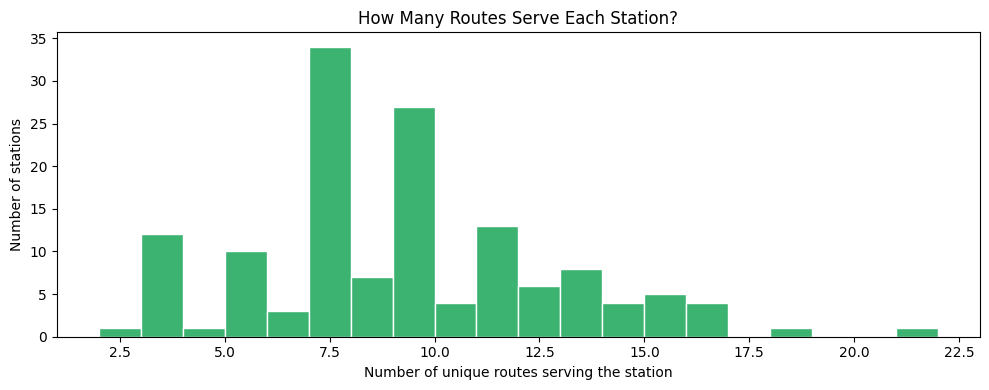

Stations served by only 1 route (vulnerable): 0
[]


In [10]:
# How many unique routes serve each station?
routes_per_station = routes.groupby("Station_Name")["Route_ID"].nunique().sort_values()

plt.figure(figsize=(10, 4))
plt.hist(routes_per_station.values, bins=20, color="mediumseagreen", edgecolor="white")
plt.xlabel("Number of unique routes serving the station")
plt.ylabel("Number of stations")
plt.title("How Many Routes Serve Each Station?")
plt.tight_layout()
plt.show()

vulnerable = routes_per_station[routes_per_station == 1]
print(f"Stations served by only 1 route (vulnerable): {len(vulnerable)}")
print(vulnerable.index.tolist())

## 9. Transfers Needed — How connected is the network really?
For a random pair of stations, how many stops does it take to get there?
This gives us a feel for the real-world routing experience.

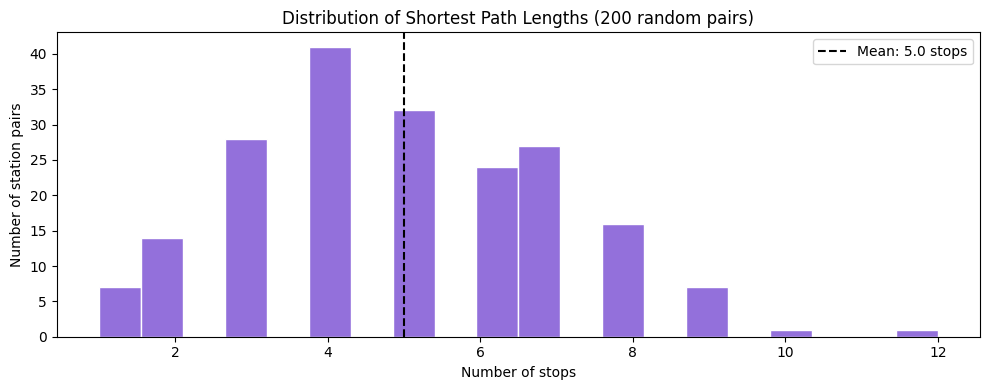

Average journey: 5.0 stops
Longest shortest path: 12 stops
Shortest path found: 1 stops


In [11]:
import random

random.seed(42)

nodes = list(G.nodes)
sample_pairs = [(random.choice(nodes), random.choice(nodes)) for _ in range(200)]

path_lengths = []
for origin, destination in sample_pairs:
    if origin != destination:
        try:
            length = nx.shortest_path_length(G, origin, destination, weight="weight")
            path_lengths.append(length)
        except nx.NetworkXNoPath:
            pass

plt.figure(figsize=(10, 4))
plt.hist(path_lengths, bins=20, color="mediumpurple", edgecolor="white")
plt.axvline(
    sum(path_lengths) / len(path_lengths),
    color="black",
    linestyle="--",
    label=f"Mean: {sum(path_lengths) / len(path_lengths):.1f} stops",
)
plt.xlabel("Number of stops")
plt.ylabel("Number of station pairs")
plt.title("Distribution of Shortest Path Lengths (200 random pairs)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average journey: {sum(path_lengths) / len(path_lengths):.1f} stops")
print(f"Longest shortest path: {max(path_lengths)} stops")
print(f"Shortest path found: {min(path_lengths)} stops")